In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from figures_setup import *
from utils import set_color_code

## Read data: chemotherapy time course

In [3]:
# Read input data
file = os.path.join(dir_data, "Org_chemo_LM3_woCC.h5ad")
adata = sc.read_h5ad(file)

In [9]:
# Set clustering resolution used in manuscript
leiden_key = 'leiden_0.6'
sc.tl.leiden(adata, resolution=0.6, key_added=leiden_key)

/tmp/ipykernel_3987984/1536950157.py:3: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.6, key_added=leiden_key)


In [4]:
# Import magic imputation results
import utils
utils.import_magic(adata, final_id='Org_chemo_LM3_woCC')

Importing MAGIC results...
4937 missing genes will be added to magic matrix with zero counts.


In [ ]:
# Add time annotation
from utils_chemo_timecourse import color_code
import utils_chemo_timecourse as utils_spec

utils_spec.add_time(adata)
utils.set_uns_colors(adata, color_code, 'time')

## UMAP representation

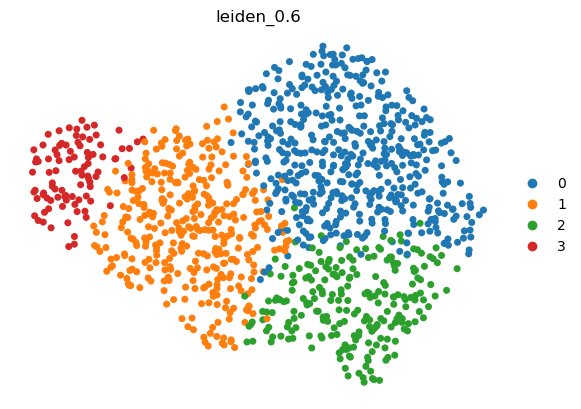

In [12]:
# Annotation UMAP
sc.pl.umap(adata, color=[leiden_key], frameon=False, title=None)

/tmp/ipykernel_3987984/3177545037.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  freq = adata.obs.pivot_table(index='time', columns=leiden_key,


           rel_no_cells                               
leiden_0.6            0          1         2         3
time                                                  
0h             1.869159  14.018692  0.000000  84.11215
12h            0.636943  96.815287  2.547771   0.00000


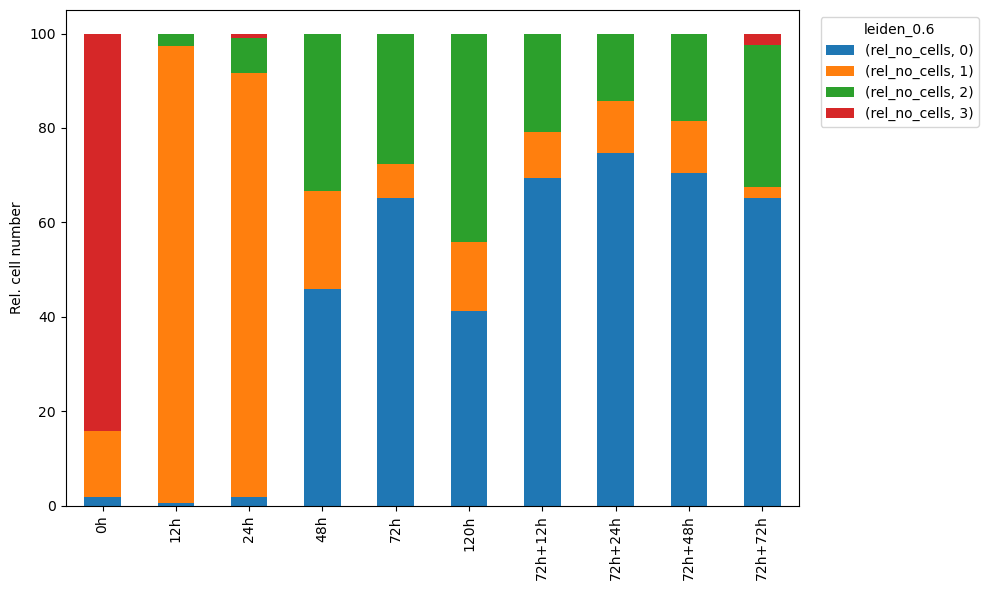

In [13]:
# Get cluster composition
cell_bc = 'cell_bc'
if cell_bc not in adata.obs.columns:
    adata.obs[cell_bc] = adata.obs.index
freq = adata.obs.pivot_table(index='time', columns=leiden_key, 
                             values=[cell_bc], aggfunc={cell_bc: 'count'})
# Rename columns
cell_count_label = 'no_cells'
colnames = {cell_bc: cell_count_label,}
freq.rename(columns=colnames, inplace=True)

# Normalize data and write to new object
freq_rel = freq.div(freq.sum(axis=1), axis=0)*100
# Rename columns
cell_count_label = 'rel_no_cells'
colnames = {'no_cells': cell_count_label,}
freq_rel.rename(columns=colnames, inplace=True)

print(freq_rel.head(2))


# df = adata.obs.groupby(['time', leiden_key]).size().unstack(fill_value=0)
# df = df.div(df.sum(axis=1), axis=0)
# df = df.reset_index().melt(id_vars='time', var_name=leiden_key, value_name='proportion')
# df[leiden_key] = df[leiden_key].astype(int) 

# Stacked bar plot
fig, ax = plt.subplots(figsize=(10, 6))
freq_rel.plot(
    kind='bar', 
    stacked=True, 
    ax=ax, 
    color=adata.uns[f'{leiden_key}_colors'][:freq_rel.shape[1]]
)

ax.set_ylabel('Rel. cell number')
ax.set_xlabel('')
ax.legend(title=leiden_key, bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

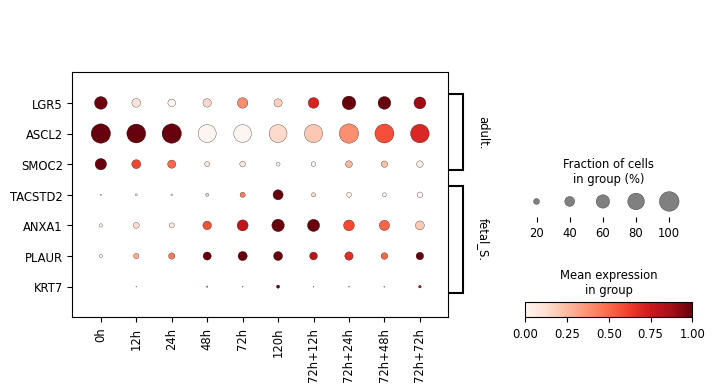

In [23]:
# Make dotplot over feature
marker_genes_dict = {
    "adult_SC": ["LGR5", "ASCL2", 'SMOC2'],
    "fetal_SC": ["TACSTD2", "ANXA1", "PLAUR", "KRT7"],
}

fig, ax = plt.subplots(figsize=(8,4))
sc.pl.dotplot(adata,
                marker_genes_dict,
                groupby='time',
                standard_scale='var',
                swap_axes=True,
                ax=ax,
            )
fig.tight_layout()
fig.show()

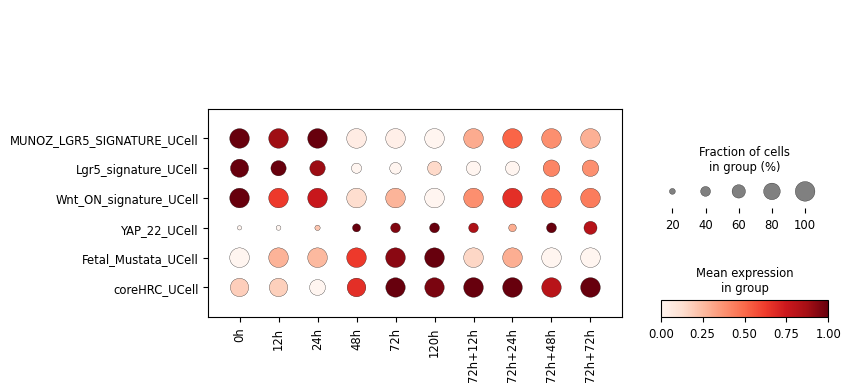

In [28]:
# Make dotplot over feature
feature = 'time'
marker_genesets = [
    'MUNOZ_LGR5_SIGNATURE_UCell',
    'Lgr5_signature_UCell', # used by Rene in current Fig i.
    'Wnt_ON_signature_UCell',
    'YAP_22_UCell',
    'Fetal_Mustata_UCell',
    'coreHRC_UCell',
]

fig, ax = plt.subplots(figsize=(8,4))
sc.pl.dotplot(adata,
                marker_genesets,
                groupby=feature,
                standard_scale='var',
                swap_axes=True,
                ax=ax,
            )
fig.tight_layout()
fig.show()

## DGEA cluster 0 vs cluster 2 (tbc)

In [45]:
# Import gene sets
print("Writing gene set details into anndata object...")
adata = utils_spec.get_gene_sets(adata)

# Get gene sets from anndata object
net = adata.uns['gene_sets']

Writing gene set details into anndata object...
Get Gregorieff YAP gene set
Genes with opposing directionality in YapKO and YapOE will be filtered out.
Genes with an absolute fold change of log2(1.2) will be kept.
98.52% of the geneset score_YAP (1199 out of 1217 genes) are included in dataset.
Process fetal gene set
98.47% of the geneset score_fetal (258 out of 262 genes) are included in dataset.
Process LGR5 gene set
99.39% of the geneset score_Lgr5 (326 out of 328 genes) are included in dataset.
Process Ganesh gene set collection
98.23% of the geneset score_fetal_Moorman (111 out of 113 genes) are included in dataset.
94.27% of the geneset score_squamous_Moorman (263 out of 279 genes) are included in dataset.
93.46% of the geneset score_neuroendocrine_Moorman (143 out of 153 genes) are included in dataset.
Process EMP1-related gene sets
94.66% of the geneset score_allHR (2393 out of 2528 genes) are included in dataset.
95.00% of the geneset score_coreHR (95 out of 100 genes) are inc

In [46]:
# Perform network check
import utils_genelist as genelist
net = genelist.pre_network_checks(
    net = net, 
    var_names = adata.var_names, 
    source='gene_set', 
    target='gene', 
    weight='weight',
)

/omics/groups/OE0285/internal/puschhof/github_projects/TROP2_in_CRC/figures/utils_genelist.py:694: UserWarning: Skipping score_Mex3a_Barriga (less than 5 overlapping genes)
  warnings.warn(f"Skipping {geneset} (less than 5 overlapping genes)")


In [49]:
# Differential gene expression analysis across clusters 2 and 0
sc.tl.rank_genes_groups(adata, groupby=leiden_key, groups=['2'], reference='0',
                        pts=True, use_raw=True,
                        method='wilcoxon',
                        corr_method='benjamini-hochberg')
df_dgea = sc.get.rank_genes_groups_df(adata, group=None)

In [52]:
def get_anndata_from_file(data_path=None, filename=None,
                          df=None,
                          stat_key='stat',
                          feature_key='names'):
    """
    Read anndata object from file.
    
    Args:
        data_path: path to data file
        filename: name of data file
        
    Returns:
        adata: anndata object
    """

    # Test if input data is provided
    if df is None and not os.path.exists(os.path.join(data_path, filename)):
        raise ValueError("Input data not correctly defined. Provide dataframe or input file.")

    # Read data from file if required
    if df is None:
        if not os.path.exists(os.path.join(data_path, filename)):
            raise ValueError(f"File not found: {filename}")
        if filename.endswith(".h5ad"):
            adata = sc.read_h5ad(os.path.join(data_path, filename))
            if adata.raw is None:
                if 'normalized' in adata.layers.keys():
                    print("Set raw to normalized")
                    adata.raw = adata.layers['normalized'].copy()
        elif filename.endswith(".pkl"):
            df = pd.read_pickle(os.path.join(data_path, filename))
            # Convert to Anndata object
            adata = anndata.AnnData(df)
            adata.obs['contrast'] = df.index  # Adds the comparison labels as metadata in obs
            adata.var_names = df.T.index
            adata.raw = adata
        elif filename.endswith(".csv"):
            df = pd.read_csv(os.path.join(data_path, filename))
            # Rename columns if applicable
            if stat_key not in df.columns and 'scores' in df.columns:
                print(f"Rename column 'scores' to {stat_key}")
                df.rename(columns={'scores': stat_key}, inplace=True)
        else:
            raise ValueError(f"File format not implemented: {filename}")

    ### Construct adata from DGEA result if needed
    print('Construct adata from DGEA results')
    if 'contrast' not in df.columns:
        if 'group' in df.columns:
            df['contrast'] = [f"{g}-vs-rest" for g in df['group']]
        else:
            df['contrast'] = 'test_vs_ref'
    elif 'group' in df.columns:
        df['contrast'] = [f"{g}-vs-all" for g in df['group']]
        
    # Turn into score matrix
    df_pivot = df.pivot(index='contrast', columns=feature_key, values=stat_key)
    adata = anndata.AnnData(
        X=df_pivot.values,
        obs=pd.DataFrame(index=df_pivot.index),
        var=pd.DataFrame(index=df_pivot.columns),
    )

    # Set nan to zero
    adata.X[np.isnan(adata.X)] = 0

    adata.raw = adata

    return adata

# Get anndata object from DGEA results
ad_dgea = get_anndata_from_file(
    df=df_dgea,
    stat_key = 'scores', 
    feature_key = 'names'
)

Construct adata from DGEA results


In [ ]:
# Run enrichment method ULM
import decoupler as dc
dc.mt.ulm(
    data = ad_dgea,
    net = net,
)

# Get activities from anndata
acts = dc.pp.get_obsm(ad_dgea, key='score_ulm')

In [61]:
# Get df from enrichment results
def get_enrichment_from_adata(acts, contrast = 'contrast', name = 'source'):
        
    ''' Turn anndata object acts into pandas DataFrame with activities and p-values.'''

    # Create data frame from acts.obsm['estimate']
    act_df = pd.DataFrame(acts.X, columns=acts.var_names, index=acts.obs_names)   
    act_df = act_df.reset_index().melt(id_vars=contrast, var_name='source', value_name='acts')

    # Create data frame from acts.obsm['padj']
    key = [key for key in acts.obsm.keys() if key.startswith('padj')][0]
    pval_df = pd.DataFrame(acts.obsm[key].values, columns=acts.var_names, index=acts.obs_names)
    pval_df = pval_df.reset_index().melt(id_vars=contrast, var_name='source', value_name='padj')

    # Merge df and pval_df
    df = pd.merge(act_df, pval_df, on=[contrast, name])
    return df

# Get enrichment results in df format
df = get_enrichment_from_adata(acts, contrast = 'contrast', name = 'source') # To save to disk
df = df.sort_values(by='acts', ascending=False)
df.head(2)

,contrast,source,acts,padj
13,test_vs_ref,score_allHR,24.061540,4.511595e-125
21,test_vs_ref,score_tmeHR,23.656034,2.910717e-121


In [86]:
# Change to publication names ### To be added
from utils_chemo_timecourse import gs_names_for_pub
df['source'] = df['source'].map(gs_names_for_pub)
df.head(3)

,contrast,source,acts,padj
13,test_vs_ref,All-HRC,24.061540,4.511595e-125
21,test_vs_ref,TME-HRC,23.656034,2.910717e-121
11,test_vs_ref,YAP,16.881772,1.054520e-62


/tmp/ipykernel_3987984/3868405192.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot.rename(columns={'acts': contrast}, inplace=True)


<Figure size 300x600 with 0 Axes>

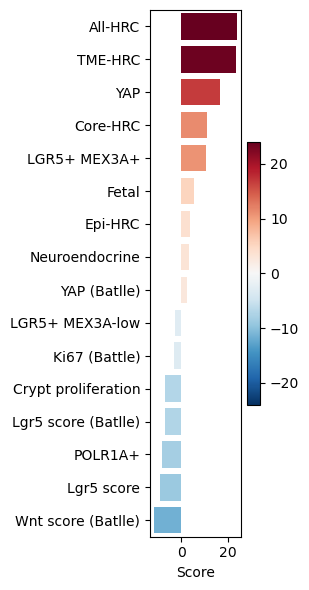

In [88]:
# Make bar plot of activities
padj_thres = 0.05

# Filter by significance
df_plot = df[df['padj'] < padj_thres]

# Restructure for plotting
contrast = 'test_vs_ref'
df_plot.rename(columns={'acts': contrast}, inplace=True)
df_plot = df_plot.drop(columns=['padj', 'contrast'])
df_plot.set_index('source', inplace=True)
df_plot = df_plot.T

# Extract maximum color range
act_min = df_plot.min().min()
act_max = df_plot.max().max()
vmax = max(abs(act_min), abs(act_max))

# Extract figure size
height = 6
width = 3
figsize = (width, height)

# Set up plot
plt.figure(figsize=figsize)
fig = dc.pl.barplot(
    data=df_plot, 
    name=contrast,
    vmin=-vmax,
    vmax=vmax,
    vcenter=0,
    return_fig=True
)
# Get the Axes from the Figure
fig.set_size_inches(figsize)
ax = fig.axes[0]
ax.set_title(f'{contrast}')
ax.set_xlabel('Score')
ax.set_ylabel('')
legend = ax.get_legend()
ax.set_title('')
fig.tight_layout()
plt.show()